<!-- mtlearn-icpr2026-doc -->
# ICPR 2026 - Plant Segmentation - ED3-NN - run_000

Paper: **A trainable connected filter preprocessing layer based on component trees**.

This notebook reproduces the representative `run_000` execution for the `Plant Segmentation / ED3-NN` configuration. It compares the baseline backbone against the same backbone preceded by Connected Filter Preprocessing (CFP).

| Field | Value |
| --- | --- |
| Dataset | Plant Segmentation |
| Dataset key | `plants_segmentation` |
| Task | Foreground/background plant segmentation |
| Backbone | ED3-NN |
| Variants | Baseline, CFP |
| Run | `run_000` |
| Seed | `2684470948` |
| Paper role | Representative run for the corresponding paper configuration |

The paper aggregates were computed from 10 independent seeds per configuration. This notebook keeps one executed run as a readable and rerunnable artifact for RRPR review.


<!-- mtlearn-icpr2026-doc -->
## Run Parameters

The first cells define the run identifier, random seed, and output directory used by the executed experiment. They are kept as code cells so the notebook remains compatible with Papermill-style batch execution.


<!-- mtlearn-icpr2026-doc -->
## Paper Output Map

- Table 1 (PP / plant segmentation metrics): the single-run metric rows are extracted from `results_df_base` in **Baseline Evaluation** and `results_df` in **CFP Evaluation**. The paper table reports mean and standard deviation over 10 runs, so this notebook provides the representative `run_000` execution.
- Figure 3: Figure 3 qualitative ED3-NN panels for this dataset are extracted from the Figure 3 Panels section.
- Table 3: Table 3(a) attribute-ablation values are extracted from the Attribute Ablation section.


In [2]:
# Parameters
RUN_ID = 0
SEED = 2684470948
OUTPUT_DIR = None
DATASET_SCALE_IN = False


<!-- mtlearn-icpr2026-doc -->
## Environment and Helpers

This setup imports PyTorch, MTLearn morphology utilities, plotting utilities, and the shared RRPR notebook helpers from `icpr2026_utils.py`. The selected device follows this priority: CUDA, Apple MPS, then CPU.


In [3]:
from pathlib import Path
import sys

import torch
import torch.nn as nn
import numpy as np
from mtlearn import morphology
import mtlearn
import matplotlib.pyplot as plt

for helper_dir in (Path.cwd(), Path.cwd() / "notebooks" / "ICPR2026"):
    if (helper_dir / "icpr2026_utils.py").exists():
        sys.path.insert(0, str(helper_dir.resolve()))
        break
else:
    raise FileNotFoundError("Could not locate notebooks/ICPR2026/icpr2026_utils.py")

from icpr2026_utils import (
    default_device,
    evaluate_train_test,
    fix_randomness,
    rank_cfp_attributes,
    save_evaluation_tables,
    show_figure3_panels,
    train_with_notebook_context,
)

np.set_printoptions(precision=3, suppress=True)
fix_randomness(SEED)
generator = torch.Generator(device="cpu")
generator.manual_seed(SEED)

device = default_device()
print("Device:", device)


Device: mps


# Dataset


<!-- mtlearn-icpr2026-doc -->
The plant dataset is loaded through `mtlearn.data.ensure_dataset("plants_segmentation")`. Because the plant image collection is not bundled with the public repository, it must be requested from the plant phenotyping dataset portal at https://www.plant-phenotyping.org/datasets-home and configured locally before this notebook can be rerun. The dataset section resizes the input images, builds the train/test split, and prepares tensors for binary segmentation. The next cell also estimates foreground/background imbalance so the loss can compensate for sparse positive pixels.


In [4]:
num_cols, num_rows =(int(1177 * 0.5), int(1324 * 0.499))
print("Resolution: ", num_cols, "x", num_rows)

dir_name = str(mtlearn.data.ensure_dataset("plants_segmentation"))
dataset = mtlearn.datasets.PairedImageDataset(root_dir=dir_name, grayscale_in=True,  num_rows=num_rows, num_cols=num_cols, scale_in=DATASET_SCALE_IN, suffix_in="_tfb", suffix_target="_fg")
trainset, testset = dataset.train_test_split(test_size=0.3, random_state=SEED)
print("Train set:", len(trainset))
print("Test set:", len(testset))

# Move train/test sets to the selected device
trainset = [(inputs.to(device), targets.to(device), file_names) for inputs, targets, file_names in trainset]
testset= [(inputs.to(device), targets.to(device), file_names) for inputs, targets, file_names in testset]
trainloader = torch.utils.data.DataLoader(trainset, batch_size=8, shuffle=True, pin_memory=False, generator=generator)


Resolution:  588 x 660
plants_segmentation: using MTLEARN_PLANTS_DATASET at /Volumes/SSD/GitHub/mtlearn/build/notebook-equivalence/20260910-pr383f27d/inputs/PlantDataset
Train set: 48
Test set: 21


In [5]:
# Compute the class-imbalance ratio
num_neg = []
num_pos = []
for i in range(len(trainset)):
    x, y, _ = trainset[i]
    num_neg.append((y == 0).sum().item())
    num_pos.append((y == 1).sum().item())

# Compute class proportions
total_neg = sum(num_neg)
total_pos = sum(num_pos)
total_samples = total_neg + total_pos

percent_neg = (total_neg / total_samples) * 100
percent_pos = (total_pos / total_samples) * 100

print(f"Total class 0 samples: {total_neg} ({percent_neg:.2f}%)")
print(f"Total class 1 samples: {total_pos} ({percent_pos:.2f}%)")

pos_weight = torch.tensor([total_neg / total_pos])  # 8498057 / 530683 ~= 16
print(f"pos_weight: {pos_weight}")


Total class 0 samples: 17528157 (94.10%)
Total class 1 samples: 1099683 (5.90%)
pos_weight: tensor([15.9393])


# Models


<!-- mtlearn-icpr2026-doc -->
The model section defines two comparable variants. `BaseNet` is the ED3-NN backbone used as the neural baseline. `BackboneWithConnectedFilterLayer` wraps the same backbone with a CFP layer so the network receives a learnable connected-filtered representation before segmentation.


In [6]:
import torch
import torch.nn as nn

class BaseNet(nn.Module):
    """ED3-NN segmentation backbone used as the baseline network."""
    def __init__(self, num_rows, num_cols, device='cpu'):
        """Create the backbone layers and move the module to the selected device."""
        super(BaseNet, self).__init__()
        self.device = device
        in_channels=1
        # ===== Encoder =====
        self.enc1 = nn.Sequential(
            nn.Conv2d(in_channels, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True)
        )
        self.pool1 = nn.MaxPool2d(2)   # 128 -> 64

        self.enc2 = nn.Sequential(
            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )
        self.pool2 = nn.MaxPool2d(2)   # 64 -> 32

        # ===== Bottleneck =====
        self.bottleneck = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )

        self.down1 = nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1)
        self.up1   = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)

        # ===== Decoder =====
        self.up1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.dec1 = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )

        self.up2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.dec2 = nn.Sequential(
            nn.Conv2d(32, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True)
        )

        # ===== Output =====
        self.out_conv = nn.Conv2d(16, 1, 1)  # logit output

        # ===== He initialization for ReLU =====
        self.apply(self.init_weights_kaiming)
        self.to(device)

    def init_weights_kaiming(self, m):
        """Initialize convolutional and linear layers with Kaiming normal weights."""
        if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        """Run the backbone forward pass and return segmentation logits."""
        if type(x) == list:
            x = x[0]

        # Encoder
        x1 = self.enc1(x)
        x2 = self.pool1(x1)
        x3 = self.enc2(x2)
        x4 = self.pool2(x3)

        # Bottleneck
        x5 = self.bottleneck(x4)

        # Decoder (sem skip connections)
        x6 = self.up1(x5)
        x6 = self.dec1(x6)
        x7 = self.up2(x6)
        x7 = self.dec2(x7)

        # Output logits
        out = self.out_conv(x7)
        return out



class BackboneWithConnectedFilterLayer(nn.Module):
    """Compose the CFP layer with the backbone for CFP-enhanced segmentation."""
    def __init__(self, layer_connected_filter, num_rows, num_cols, unet=None, device='cpu'):
        """Store the CFP layer, create the downstream backbone, and keep both on the selected device."""
        super(BackboneWithConnectedFilterLayer, self).__init__()
        self.device = device
        self.morphological_layer = layer_connected_filter
        self.net = BaseNet(num_rows, num_cols, device)

    def forward(self, inputs):
        """Apply CFP to the input image and feed the filtered tensor into the backbone."""
        h_filter = self.morphological_layer(inputs)
        self.h_filter = h_filter
        return self.net(self.h_filter)


<!-- mtlearn-icpr2026-doc -->
## CFP Layer Configuration

The CFP layer is configured with a max-tree and a set of morphological attributes. During training, the layer learns how to combine connected filters before passing the transformed image to the backbone, allowing the comparison to isolate the effect of morphological preprocessing.


In [7]:
Type = morphology.AttributeType
tree_type = morphology.TreeType.MAX_TREE
layer_connected_filter = mtlearn.layers.ConnectedFilterPreprocessingLayer(
    in_channels=1,
    filter_specs=[
        {
            "tree_type": tree_type,
            "attributes": (
                Type.AREA,
                Type.INERTIA,
                Type.GRAY_LEVEL_HEIGHT,
                Type.GRAY_LEVEL_VARIANCE,
                Type.BITQUAD_PERIMETER_CONTINUOUS,
            ),
        },
    ],
    device=device,
    scale_mode="dataset_clipped_zscore01",
    score_sharpness=1.0,
    clamp=None,
)

# Create a cached train loader used during training
trainloader_cached = layer_connected_filter.build_dataloader_cached(trainloader)
layer_connected_filter.init_identity()


()

# Training


<!-- mtlearn-icpr2026-doc -->
The training wrapper below delegates the repeated optimizer, class-balanced BCE loss, CFP auxiliary loss, and loss-curve plotting logic to `icpr2026_utils.py`. The visible calls still keep the paper parameters explicit for baseline and CFP-enhanced runs.


In [8]:
def training(model, lr=0.001, lr_cfp=0.05, lambda_filter=1, num_epochs_filter=0, num_epochs=100):
    return train_with_notebook_context(
        model,
        trainloader=trainloader,
        trainloader_cached=trainloader_cached,
        pos_weight=pos_weight,
        device=device,
        lr=lr,
        lr_cfp=lr_cfp,
        lambda_filter=lambda_filter,
        num_epochs_filter=num_epochs_filter,
        num_epochs=num_epochs,
    )


<!-- mtlearn-icpr2026-doc -->
## Baseline Training

This run trains the ED3-NN backbone without CFP. It provides the reference performance for the dataset, architecture, seed, and training schedule used in this notebook.


Epoch 0, Loss: 0.8571215, Learning rate: 0.001000


Epoch 10, Loss: 0.3114493, Learning rate: 0.001000


Epoch 20, Loss: 0.2218457, Learning rate: 0.001000


Epoch 30, Loss: 0.1665467, Learning rate: 0.001000


Epoch 40, Loss: 0.1319845, Learning rate: 0.001000


...

Epoch 60, Loss: 0.0956013, Learning rate: 0.001000


Epoch 70, Loss: 0.0860657, Learning rate: 0.001000


Epoch 80, Loss: 0.0793162, Learning rate: 0.001000


Epoch 90, Loss: 0.0712014, Learning rate: 0.001000


Epoch 99, Loss: 0.0673939, Learning rate: 0.001000
Finish training
Execution time: 12.506 minutes


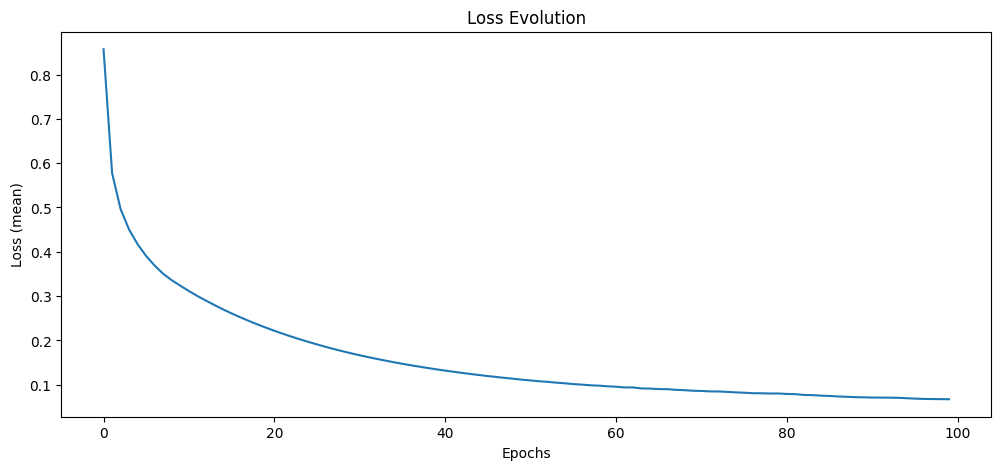

[0.8571215371290842,
 0.577664444843928,
 0.4960252692302068,
 0.44977855185667676,
 0.4167060802380244,
 0.390285203854243,
 0.3686477839946747,
 0.3501006563504537,
 0.3356890430053075,
 0.32339022556940716,
 0.3114493240912755,
 0.3001377731561661,
 0.2898140052954356,
 0.27972669899463654,
 0.27000856399536133,
 0.2609495222568512,
 0.2524033635854721,
 0.24414484947919846,
 0.23639148225386938,
 0.22895741959412894,
 0.22184566408395767,
 0.21511545777320862,
 0.20864257216453552,
 0.20250185579061508,
 0.19662352899710336,
 0.1910124197602272,
 0.18563928455114365,
 0.18051868677139282,
 0.17563257118066153,
 0.17098095764716467,
 0.16654667258262634,
 0.16234666109085083,
 0.15836143493652344,
 0.15451233088970184,
 0.15080397327740988,
 0.1472980057199796,
 0.14398574953277907,
 0.1407960851987203,
 0.13771052037676176,
 0.13475404803951582,
 0.13198447475830713,
 0.12932895496487617,
 0.12677676354845366,
 0.12422844767570496,
 0.1218907857934634,
 0.119631410886844,
 0.117616

In [9]:
model_base = BaseNet(num_rows, num_cols, device)
training(model_base, lr=0.001, num_epochs=100)


<!-- mtlearn-icpr2026-doc -->
## Backbone with CFP Training

This run trains the same backbone with CFP placed before it. The goal is to measure whether the learnable connected operator improves segmentation when all other experimental conditions remain aligned with the baseline.


Epoch 0, Loss: 104282220.0000000, Learning rate: 0.001000


	Loss (main): 0.7948769, Loss (filter): 106592800.0000000, Lambda: 1.0000


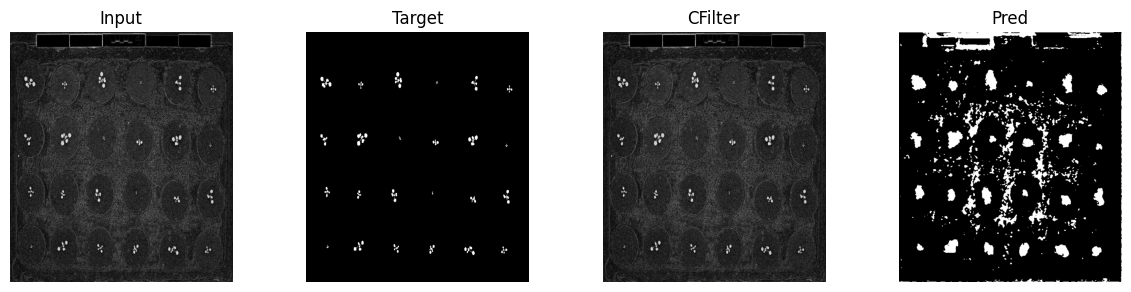

Epoch 10, Loss: 2349213.0000000, Learning rate: 0.001000


	Loss (main): 0.5035442, Loss (filter): 2964051.0000000, Lambda: 0.8000


Epoch 20, Loss: 1653231.8541667, Learning rate: 0.001000


	Loss (main): 0.3333682, Loss (filter): 2793322.7500000, Lambda: 0.6000


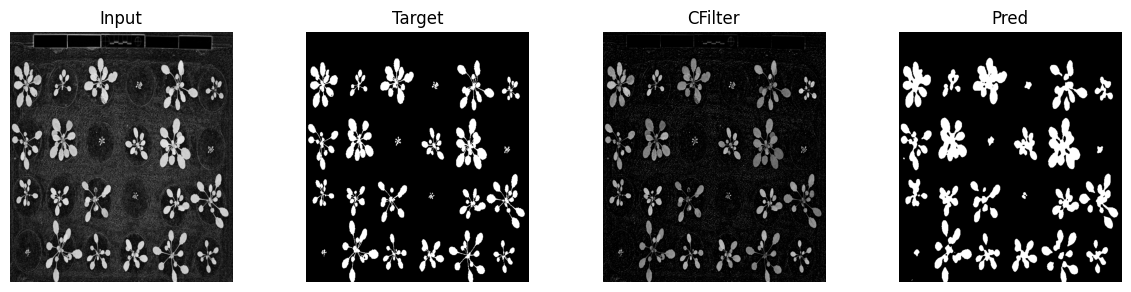

Epoch 30, Loss: 1054566.6770833, Learning rate: 0.001000


	Loss (main): 0.2238865, Loss (filter): 2697490.0000000, Lambda: 0.4000


Epoch 40, Loss: 514966.4687500, Learning rate: 0.001000


	Loss (main): 0.1524096, Loss (filter): 2655695.7500000, Lambda: 0.2000


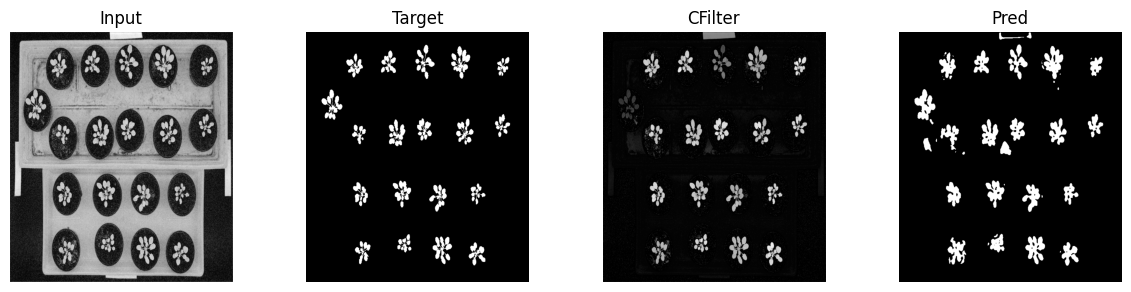

Epoch 50, Loss: 0.1776206, Learning rate: 0.001000


Epoch 60, Loss: 0.0775184, Learning rate: 0.001000


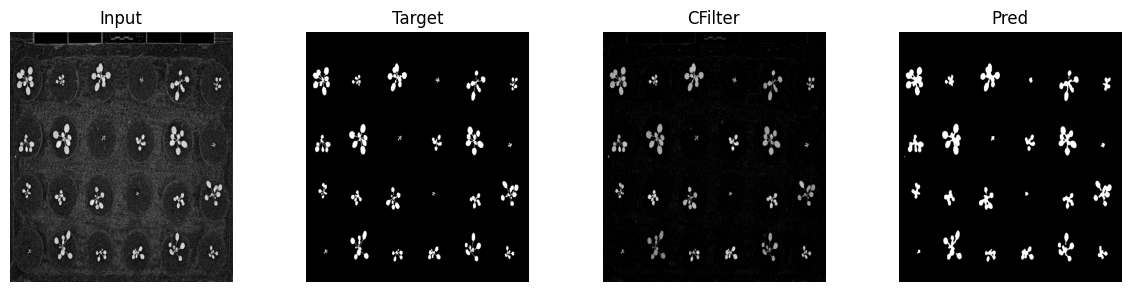

Epoch 70, Loss: 0.0684781, Learning rate: 0.001000


Epoch 80, Loss: 0.0618592, Learning rate: 0.001000


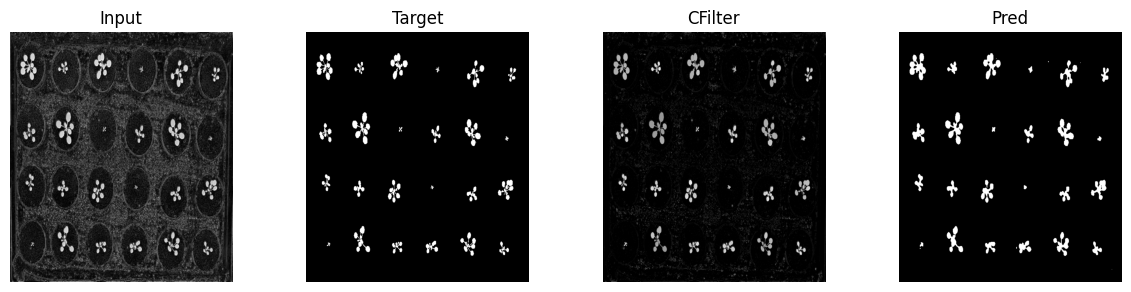

Epoch 90, Loss: 0.0577249, Learning rate: 0.001000


Epoch 99, Loss: 0.0555456, Learning rate: 0.001000


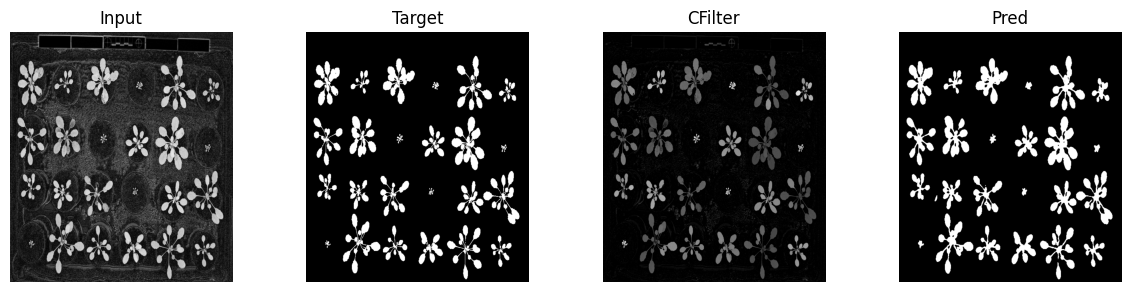

Finish training
Execution time: 13.267 minutes


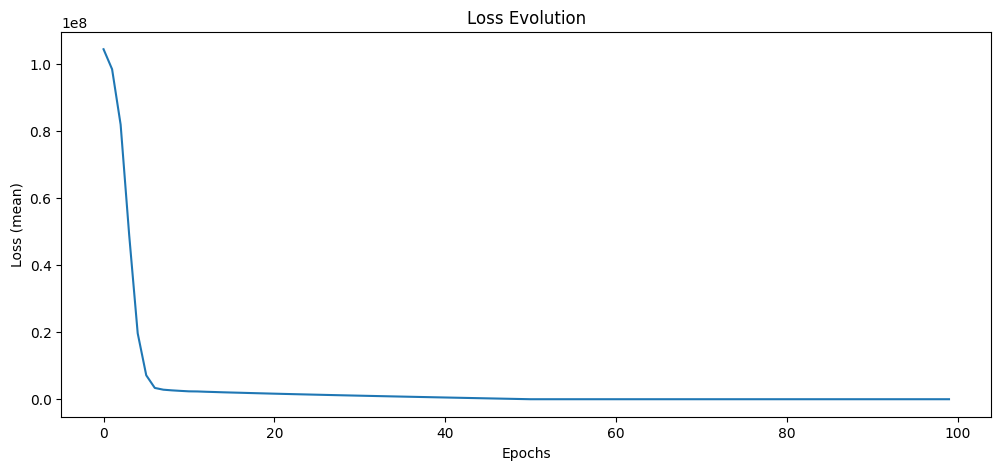

[104282220.0,
 98325738.66666667,
 81824895.33333333,
 48967385.333333336,
 19625319.833333332,
 7126179.833333333,
 3365059.625,
 2840036.9583333335,
 2641621.8333333335,
 2486785.8333333335,
 2349213.0,
 2315421.5833333335,
 2220882.625,
 2145565.875,
 2062058.6041666667,
 1992845.1666666667,
 1926888.1666666667,
 1855907.3541666667,
 1787241.7083333333,
 1719122.6666666667,
 1653231.8541666667,
 1589419.8541666667,
 1526755.3541666667,
 1464936.0,
 1403922.1041666667,
 1343700.9166666667,
 1284343.625,
 1225849.0625,
 1168115.7708333333,
 1111043.1458333333,
 1054566.6770833333,
 998653.7604166666,
 943279.5104166666,
 888409.1145833334,
 833995.2291666666,
 779993.1041666666,
 726363.90625,
 673076.4583333334,
 620099.9583333334,
 567405.90625,
 514966.46875,
 462754.9114583333,
 410748.2083333333,
 358926.4010416667,
 307270.3177083333,
 255763.57291666666,
 204391.046875,
 153139.26302083334,
 101996.69140625,
 50953.282552083336,
 0.17762060463428497,
 0.12796381736795107,
 0.14

In [10]:
model = BackboneWithConnectedFilterLayer(layer_connected_filter, num_rows, num_cols, device=device)
training(model, lr=0.001, lr_cfp=0.05, num_epochs_filter=50, num_epochs=100)


<!-- mtlearn-icpr2026-doc -->
## Threshold Selection and Metrics

The shared helpers select the `train_pr` operating threshold on the training split using the precision-recall F1 criterion, then build the Train/Test metric tables in the evaluation cells below. This notebook uses `metric_average="global"` for the metric aggregation mode.


<!-- mtlearn-icpr2026-doc -->
## Baseline Evaluation

**Paper extraction: Table 1, `ED3-NN` without CFP.** The next code cell selects the `train_pr` operating threshold on the training split, evaluates the baseline on train/test splits, and exposes the `ED3-NN` without-CFP metric rows in `results_df_base`. The test row is the value aggregated for Table 1.


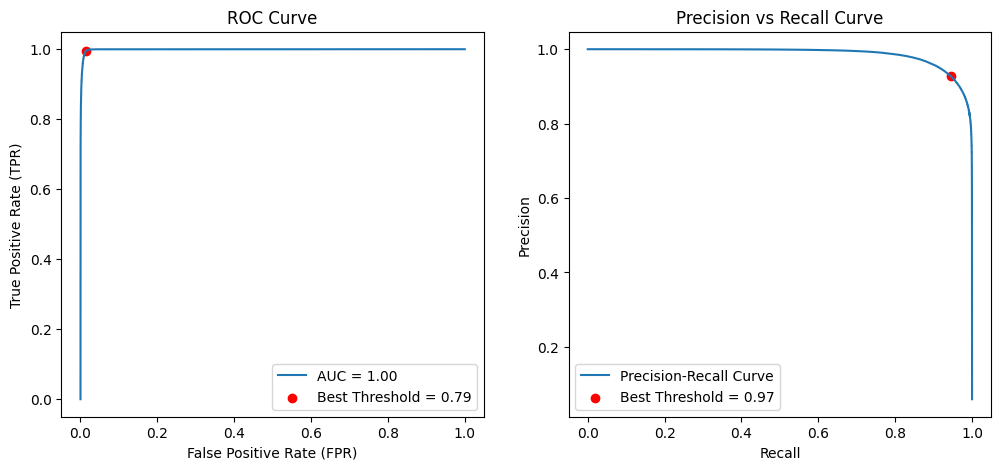

Train ROC threshold: 0.79
Train precision-recall threshold: 0.97


,Accuracy,Precision,Recall (Sensitivity),Specificity,F1-Score,AUC-ROC,Jaccard Index,Cohen's Kappa,MCC,Threshold
Train,0.992356,0.926726,0.945257,0.995311,0.935900,0.999137,0.879522,0.931836,0.931887,0.972623
Test,0.992926,0.915796,0.946349,0.995393,0.930822,0.999177,0.870595,0.927095,0.927234,0.972623


In [11]:
threshold_base, results_df_base = evaluate_train_test(
    model_base,
    trainset,
    testset,
    metric_average="global",
)
save_evaluation_tables(
    OUTPUT_DIR,
    "base",
    results_df_base,
    metadata={
        "DATASET": "Plants",
        "MODEL": "ED3-NN",
        "VARIANT": "Baseline",
        "RUN_ID": RUN_ID,
        "SEED": SEED,
    },
)
results_df_base


<!-- mtlearn-icpr2026-doc -->
## CFP Evaluation

**Paper extraction: Table 1, `ED3-NN` with CFP.** The next code cell selects the `train_pr` operating threshold on the training split, evaluates the CFP model on train/test splits, and exposes the `ED3-NN` with-CFP metric rows in `results_df`. The test row is the value aggregated for Table 1.


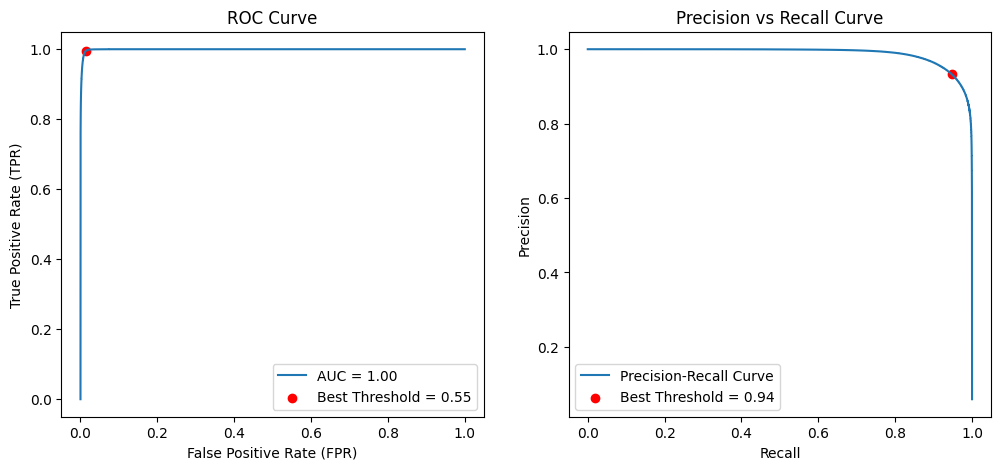

Train ROC threshold: 0.55
Train precision-recall threshold: 0.94


,Accuracy,Precision,Recall (Sensitivity),Specificity,F1-Score,AUC-ROC,Jaccard Index,Cohen's Kappa,MCC,Threshold
Train,0.992847,0.932226,0.947729,0.995677,0.939914,0.999260,0.886639,0.936111,0.936147,0.937718
Test,0.993224,0.921202,0.946193,0.995714,0.933530,0.999231,0.875346,0.929961,0.930053,0.937718


In [12]:
threshold, results_df = evaluate_train_test(
    model,
    trainset,
    testset,
    metric_average="global",
)
save_evaluation_tables(
    OUTPUT_DIR,
    "cfp",
    results_df,
    metadata={
        "DATASET": "Plants",
        "MODEL": "ED3-NN",
        "VARIANT": "CFP",
        "RUN_ID": RUN_ID,
        "SEED": SEED,
    },
)
results_df


<!-- mtlearn-icpr2026-doc -->
## Figure 3 Panels

**Paper extraction: Figure 3, PP / plant segmentation, ED3-NN row panels.** The next code cell extracts the five qualitative panels used for Figure 3-style inspection: input image, target mask, baseline prediction, CFP-layer output, and CFP prediction. The paper figure uses selected ConvNet and ED3-NN examples; `sample_index` can be changed to inspect the candidate image used for the final figure.


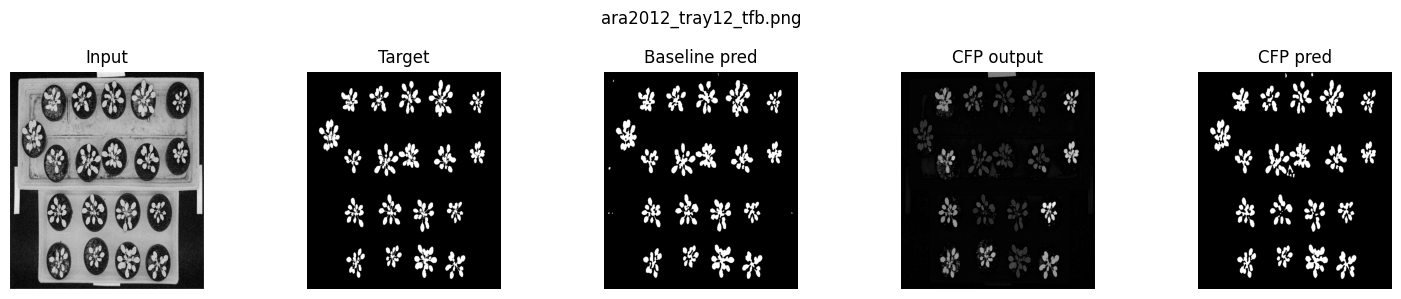

In [13]:
show_figure3_panels(
    model_base,
    model,
    testset,
    device=device,
    threshold_base=threshold_base,
    threshold=threshold,
    sample_index=0,
)


<!-- mtlearn-icpr2026-doc -->
## Attribute Ablation

**Paper extraction: Table 3(a), `PP / plant segmentation` attribute-level gate ablation on ED3-NN.** The next code cell removes one attribute contribution at a time from the CFP gate logit and exposes `attribute_ablation_df`, including mean absolute gate change, standard deviation, sample count, and relative contribution percentage. The paper table reports this analysis for ED3-NN only.


In [14]:
attribute_ablation_df = rank_cfp_attributes(model, testset, device=device)
attribute_ablation_df


,spec,attribute,mean_abs_delta_p,std_abs_delta_p,n,contribution_percent
0,spec_000,AREA,0.260335,0.016573,21,40.513543
1,spec_000,BITQUAD_PERIMETER_CONTINUOUS,0.245089,0.016486,21,38.140935
2,spec_000,INERTIA,0.113246,0.013688,21,17.623455
3,spec_000,GRAY_LEVEL_HEIGHT,0.022247,0.003338,21,3.462103
4,spec_000,GRAY_LEVEL_VARIANCE,0.001670,0.000321,21,0.259964
